In [1]:
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import glob

In [4]:
#Define output directory for the data
datadir = '/home/jovyan/SAMBBA_data/'

In [5]:
with open(datadir+'/man-sp2_faam_20120929_r0_b746.na', "rb") as f:
    lines_sp2 = f.readlines()  # Read the first 100 bytes
with open(datadir+'/man-ams_faam_20120929_r0_b746.na', "rb") as f:
    lines_ams = f.readlines()  # Read the first 100 bytes

In [6]:
metadata_lines_sp2 = lines_sp2[:39]  # Assume first 5 lines are metadata
header_line_sp2 = metadata_lines_sp2[38].strip().split()  # Extract header names
# Decode if header contains byte strings
header_line_sp2 = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_sp2]
# Decode if metadata contains byte strings
metadata_lines_sp2 = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_sp2]
header_line_sp2

['Time_UTC', 'BC_mass', 'BC_number', 'Scatter_number']

In [7]:
metadata_lines_ams = lines_ams[:46]  # Assume first 5 lines are metadata
header_line_ams = metadata_lines_ams[45].strip().split()  # Extract header names
# Decode if header contains byte strings
header_line_ams = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_ams]
# Decode if metadata contains byte strings
metadata_lines_ams = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_ams]

In [8]:
data_lines_sp2 = lines_sp2[39:]  # Actual data starts after metadata
data_lines_ams = lines_ams[46:]

In [9]:
# Parse data into a NumPy array
data_array = np.array([line.strip().split() for line in data_lines_sp2], dtype=float)

# Define dimensions (assuming first column is time and others are variables)
dims = ("time", "variable")  # Modify as needed
time_coords = np.arange(data_array.shape[0])  # Placeholder for time index

# Convert to xarray Dataset with headers as variable names
ds_sp2 = xr.Dataset(
    {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_sp2)},
    coords={"time": time_coords},
    attrs={"Metadata": "\n".join(metadata_lines_sp2[:38])}  # Store metadata as an attribute
)


In [10]:
# Parse data into a NumPy array
data_array = np.array([line.strip().split() for line in data_lines_ams], dtype=float)

# Define dimensions (assuming first column is time and others are variables)
dims = ("time", "variable")  # Modify as needed
time_coords = np.arange(data_array.shape[0])  # Placeholder for time index

# Convert to xarray Dataset with headers as variable names
ds_ams = xr.Dataset(
    {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_ams)},
    coords={"time": time_coords},
    attrs={"Metadata": "\n".join(metadata_lines_ams[:45])}  # Store metadata as an attribute
)

In [11]:
def convert_time_to_datetime_sp2(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y %m %d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_ams(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y %m %d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_start_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf

In [12]:
# Example usage
start_date = "2012 09 29"  # Example start date

# Convert time
ds_sp2 = convert_time_to_datetime_sp2(ds_sp2, start_date)
ds_ams = convert_time_to_datetime_ams(ds_ams, start_date)

# Print updated dataset with datetime coordinate
#ds_ams

In [13]:
# Filter out invalid BC mass values (9999999)
valid_BC_mass_mask = ds_sp2["BC_mass"] != 9999999
filtered_ds_BC_mass = ds_sp2.where(valid_BC_mass_mask, drop=True)

# Filter out invalid SO4 values (9999999)
valid_SO4_mask = ds_ams["SO4"] != 9999999
filtered_ds_SO4 = ds_ams.where(valid_SO4_mask, drop=True)

# Filter out invalid NH4 values (9999999)
valid_NH4_mask = ds_ams["NH4"] != 9999999
filtered_ds_NH4 = ds_ams.where(valid_NH4_mask, drop=True)

# Filter out invalid ORG values (9999999)
valid_ORG_mask = ds_ams["ORG"] != 9999999
filtered_ds_ORG = ds_ams.where(valid_ORG_mask, drop=True)

# Filter out invalid NO3 values (9999999)
valid_NO3_mask = ds_ams["NO3"] != 9999999
filtered_ds_NO3 = ds_ams.where(valid_NO3_mask, drop=True)


# Filter out invalid Chl values (9999999)
valid_Chl_mask = ds_ams["Chl"] != 9999999
filtered_ds_Chl = ds_ams.where(valid_Chl_mask, drop=True)


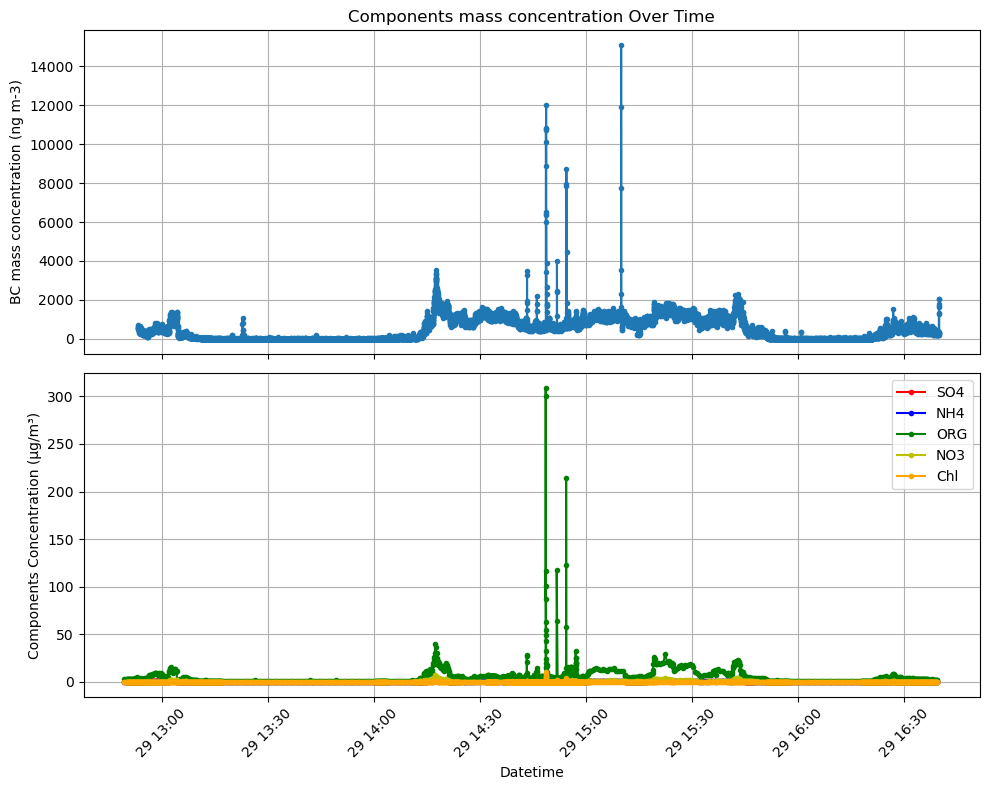

In [14]:
# Create a figure with two subplots sharing the x-axis
fig, ax1 = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- First Plot: PSAP_LOG Values ---
ax1[0].plot(filtered_ds_BC_mass.datetime, filtered_ds_BC_mass["BC_mass"],marker='.')
ax1[0].set_ylabel(r'BC mass concentration (ng m-3)')
ax1[0].grid()
ax1[0].set_title("Components mass concentration Over Time")

# --- Second Plot: Concentrations ---
ax1[1].plot(filtered_ds_SO4.datetime, filtered_ds_SO4["SO4"], label="SO4", color="r",marker='.')
ax1[1].plot(filtered_ds_SO4.datetime, filtered_ds_NH4["NH4"], label="NH4", color="b",marker='.')
ax1[1].plot(filtered_ds_SO4.datetime, filtered_ds_ORG["ORG"], label="ORG", color="g",marker='.')
#plt.plot(common_times, filtered_ds_ORG["ORG"], label="ORG", color="g")
ax1[1].plot(filtered_ds_SO4.datetime, filtered_ds_NO3["NO3"], label="NO3", color="y",marker='.')
ax1[1].plot(filtered_ds_SO4.datetime, filtered_ds_Chl["Chl"], label="Chl", color="orange",marker='.')

ax1[1].set_xlabel("Datetime")
ax1[1].set_ylabel("Components Concentration (µg/m³)")
ax1[1].grid()
ax1[1].legend()

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the figure
plt.show()


In [15]:
# Convert BC_mass from ng/m³ to µg/m³ (1 ng = 0.001 µg)
filtered_ds_BC_mass["BC_mass_ug"] = filtered_ds_BC_mass["BC_mass"] * 0.001

# Interpolate BC_mass_ug to match the timestamps of filtered_ds_SO4
bc_mass_interp = np.interp(
    filtered_ds_SO4.datetime.astype('int64'),   # Target time (SO4)
    filtered_ds_BC_mass.datetime.astype('int64'), # Original BC_mass time
    filtered_ds_BC_mass["BC_mass_ug"] # Original BC_mass values
)

# Compute total mass concentration
total_mass = (
    bc_mass_interp + 
    filtered_ds_SO4["SO4"] +
    filtered_ds_NH4["NH4"] +
    filtered_ds_ORG["ORG"] +
    filtered_ds_NO3["NO3"] +
    filtered_ds_Chl["Chl"]
)

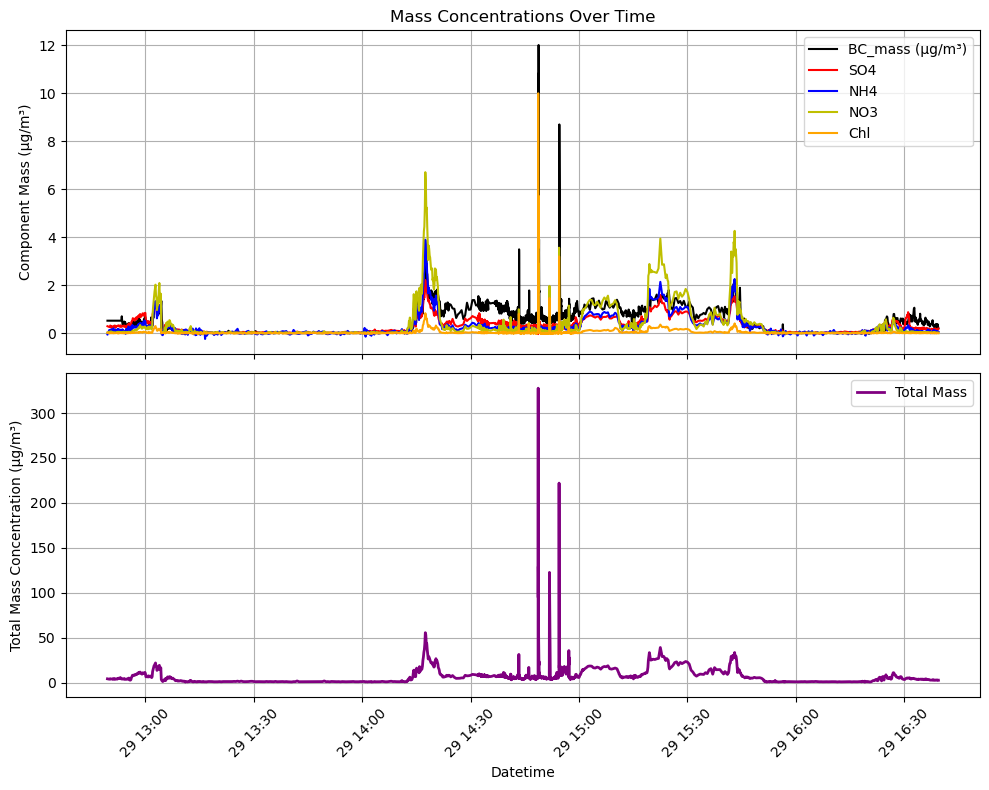

In [16]:
# Create a figure with two subplots sharing the x-axis
fig, ax1 = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- First Plot: Individual Components ---
ax1[0].plot(filtered_ds_SO4.datetime, bc_mass_interp, label="BC_mass (µg/m³)", color="k")
ax1[0].plot(filtered_ds_SO4.datetime, filtered_ds_SO4["SO4"], label="SO4", color="r")
ax1[0].plot(filtered_ds_SO4.datetime, filtered_ds_NH4["NH4"], label="NH4", color="b")
#ax1[0].plot(filtered_ds_SO4.datetime, filtered_ds_ORG["ORG"], label="ORG", color="g")
ax1[0].plot(filtered_ds_SO4.datetime, filtered_ds_NO3["NO3"], label="NO3", color="y")
ax1[0].plot(filtered_ds_SO4.datetime, filtered_ds_Chl["Chl"], label="Chl", color="orange")

ax1[0].set_ylabel("Component Mass (µg/m³)")
ax1[0].grid()
ax1[0].legend()
ax1[0].set_title("Mass Concentrations Over Time")

# --- Second Plot: Total Mass Concentration ---
ax1[1].plot(filtered_ds_SO4.datetime, total_mass, label="Total Mass", color="purple", linewidth=2)
ax1[1].set_xlabel("Datetime")
ax1[1].set_ylabel("Total Mass Concentration (µg/m³)")
ax1[1].grid()
ax1[1].legend()

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the figure
plt.show()


In [17]:
# Compute sum over all time points
total_mass_sum = np.nansum(total_mass)  # Avoid NaNs in summation
org_mass_sum = np.nansum(filtered_ds_ORG["ORG"])

# Compute ORG mass percentage
org_mass_percentage = (org_mass_sum / total_mass_sum) * 100

# Print results
print(f"Total mass over the period: {total_mass_sum:.2f} µg/m³")
print(f"Total ORG mass over the period: {org_mass_sum:.2f} µg/m³")
print(f"ORG mass percentage of total: {org_mass_percentage:.2f}%")

Total mass over the period: 15085.33 µg/m³
Total ORG mass over the period: 11879.13 µg/m³
ORG mass percentage of total: 78.75%


In [20]:
# Get all .nc files in the directory
file_paths = sorted(glob.glob(f'{datadir}/*746.nc'))

ds_psap = xr.open_dataset(file_paths[0])

In [21]:
filtered_time = filtered_ds_SO4.datetime.values  # Reference timestamps
psap_time = ds_psap["Time"].values  # Original timestamps from new dataset


common_times = np.intersect1d(filtered_time, psap_time)

# Create a boolean mask as an Xarray DataArray
mask = xr.DataArray(np.isin(psap_time, common_times), dims=["data_point"])

# Apply the mask to filter ds_psap
ds_psap_matched = ds_psap.where(mask, drop=True)

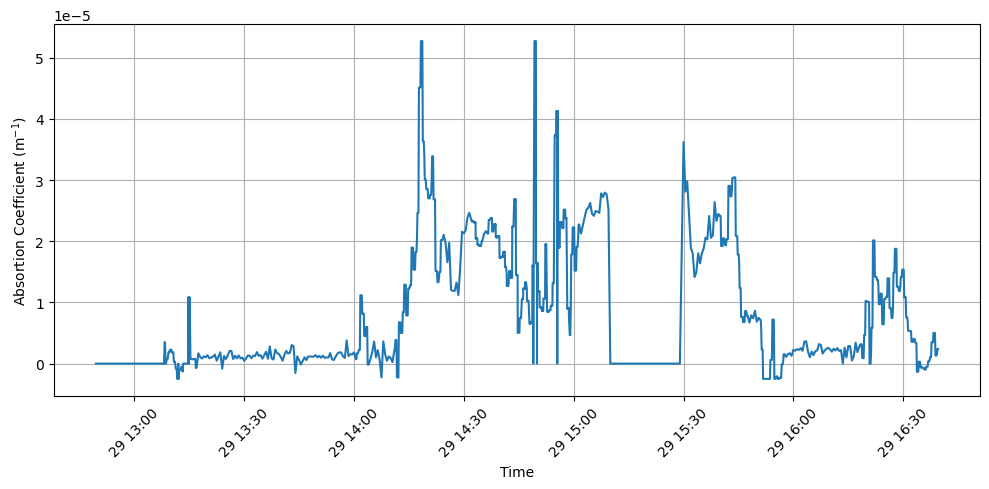

In [22]:
# Step 5: Plot the resampled PSAP_LOG values
plt.figure(figsize=(10, 5))

# Plot resampled PSAP_LOG values
plt.plot(ds_psap_matched['Time'], ds_psap_matched['PSAP_LIN'])

plt.xlabel('Time')
plt.ylabel(r'Absortion Coefficient ($\mathrm{m^{-1}}$)')
plt.xticks(rotation=45)
plt.grid()

# Tight layout for better plot formatting
plt.tight_layout()

# Show the plot
plt.show()

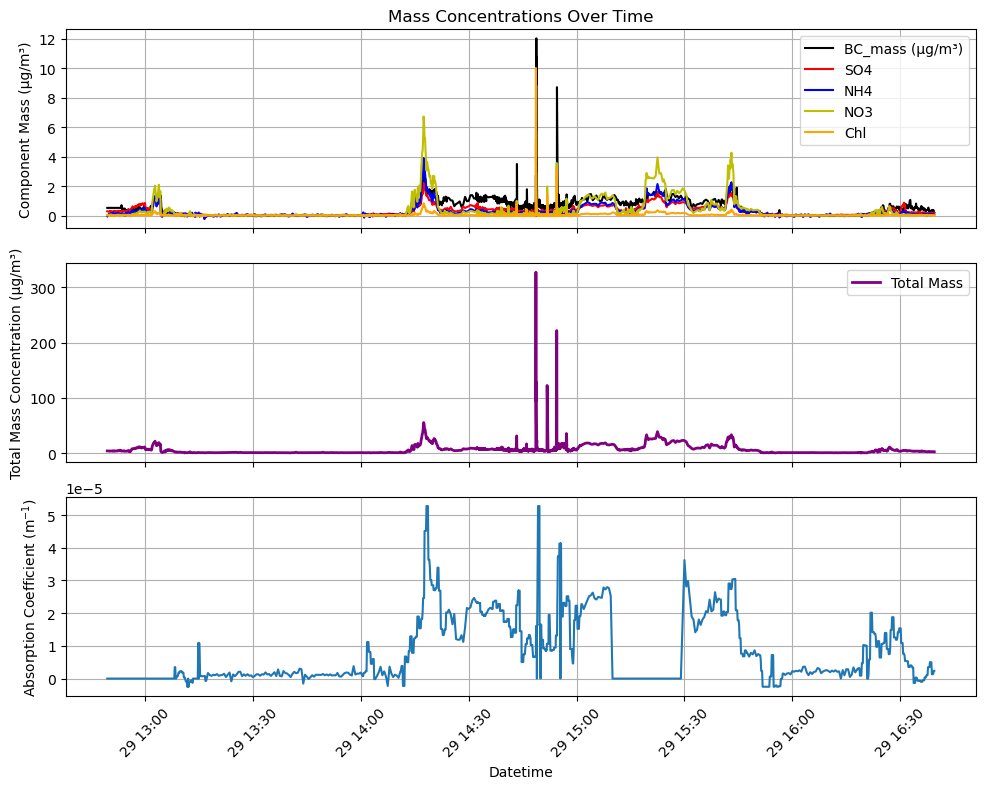

In [25]:
# Create a figure with two subplots sharing the x-axis
fig, ax1 = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# --- First Plot: Individual Components ---
ax1[0].plot(filtered_ds_SO4.datetime, bc_mass_interp, label="BC_mass (µg/m³)", color="k")
ax1[0].plot(filtered_ds_SO4.datetime, filtered_ds_SO4["SO4"], label="SO4", color="r")
ax1[0].plot(filtered_ds_SO4.datetime, filtered_ds_NH4["NH4"], label="NH4", color="b")
#ax1[0].plot(filtered_ds_SO4.datetime, filtered_ds_ORG["ORG"], label="ORG", color="g")
ax1[0].plot(filtered_ds_SO4.datetime, filtered_ds_NO3["NO3"], label="NO3", color="y")
ax1[0].plot(filtered_ds_SO4.datetime, filtered_ds_Chl["Chl"], label="Chl", color="orange")

ax1[0].set_ylabel("Component Mass (µg/m³)")
ax1[0].grid()
ax1[0].legend()
ax1[0].set_title("Mass Concentrations Over Time")

# --- Second Plot: Total Mass Concentration ---
ax1[1].plot(filtered_ds_SO4.datetime, total_mass, label="Total Mass", color="purple", linewidth=2)
ax1[1].set_ylabel("Total Mass Concentration (µg/m³)")
ax1[1].grid()
ax1[1].legend()

ax1[2].plot(ds_psap_matched['Time'], ds_psap_matched['PSAP_LIN'])
ax1[2].set_ylabel(r'Absorption Coefficient ($\mathrm{m^{-1}}$)')
ax1[2].grid()
ax1[2].set_xlabel("Datetime")
#ax1[2].set_title("PSAP Absorption and Concentration Over Time")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the figure
plt.show()


In [29]:
# Compute sum over all time points
total_absortion_sum = np.nansum(ds_psap_matched['PSAP_LIN'])  # Avoid NaNs in summation
#org_mass_sum = np.nansum(filtered_ds_ORG["ORG"])

# Compute 
mass_absortion_eff = (total_absortion_sum / total_mass_sum) 
mass_absortion_eff_g = (total_absortion_sum / (total_mass_sum*1e-6)) 
# Print results
print(f"Mass absorption efficiency over the period: {mass_absortion_eff} m²/µg")
print(f"Mass absorption efficiency over the period (g): {mass_absortion_eff_g} m²/g")

Mass absorption efficiency over the period: 1.5286865364368972e-06 m²/µg
Mass absorption efficiency over the period (g): 1.5286865364368973 m²/g
